# Clustering Validation Lecture – PANCAN Example
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [267]:
import multiprocessing
import math
import warnings

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import ParameterSampler

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

import scanpy as sc

from umap import UMAP

from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import seaborn as sns

In [306]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning, message=".*force_all_finite.*")

warnings.filterwarnings("ignore", category=FutureWarning, module="scanpy")

In [269]:
col_pal = sns.color_palette("rainbow", n_colors=8)

sns.set_theme(
    style="whitegrid",
    palette=col_pal,
    font_scale=1.2,
    rc={
        "axes.edgecolor": ".2",
        "grid.color": ".8",
        "grid.linewidth": 0.8,
        "figure.figsize": (8, 5),
        "axes.prop_cycle": plt.cycler(color=col_pal)
    }
)

sns.set_context("notebook", rc={"lines.linewidth": 2, "font.size": 14})

### 0.2 Helper Functions:

In [304]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of TCGA Pan-Cancer gene expression",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of TCGA Pan-Cancer gene expression",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of TCGA Pan-Cancer gene expression",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

In [271]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [272]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

### 0.3 Data Import:

In [274]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


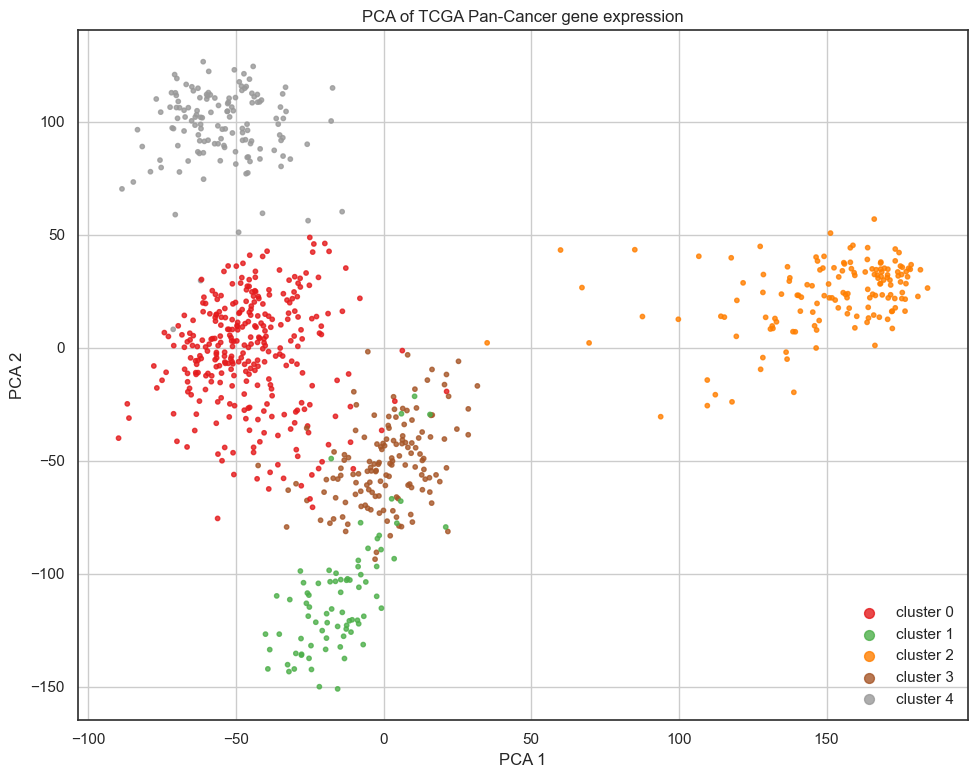

In [275]:
plot_dim_reduced_clustering(X, y, method='PCA')

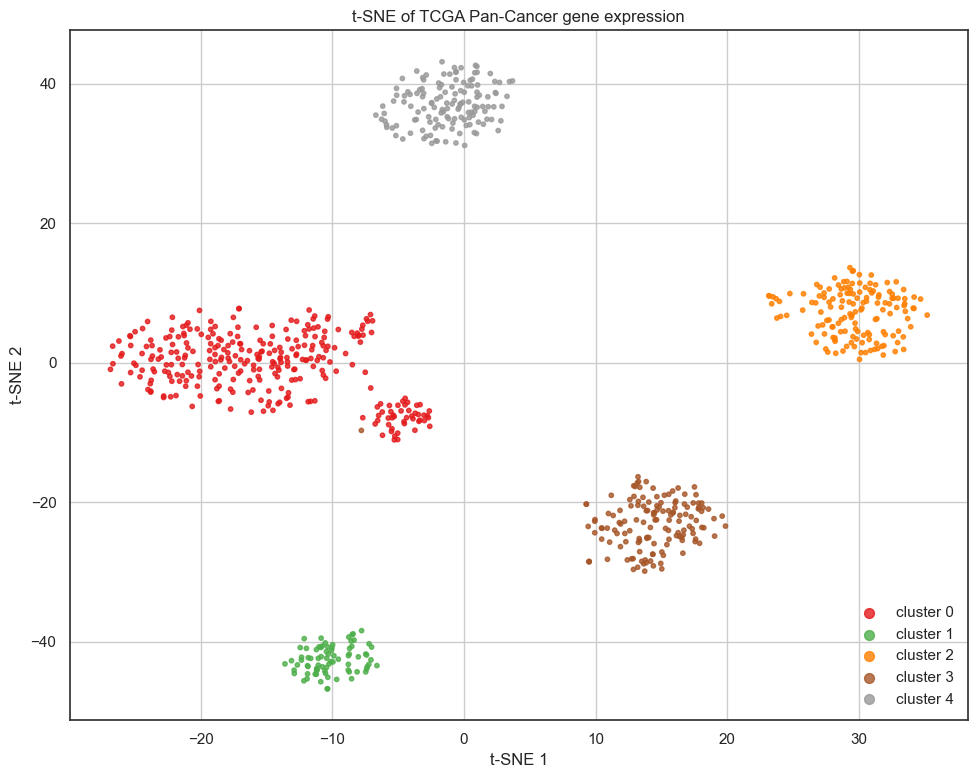

In [276]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


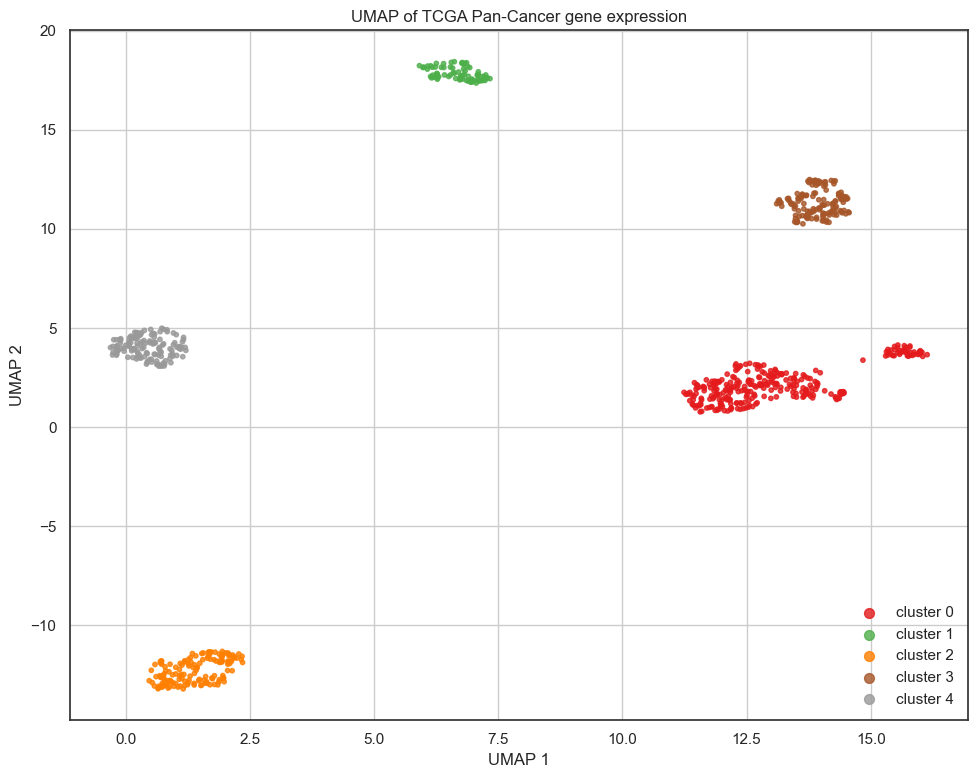

In [307]:
plot_dim_reduced_clustering(X, y, method='UMAP')

---

## 1. Clustering Pipeline and Choosing K:

### 1.1 Clustering Pipeline:

We normalize our data, apply a dimensionality reduction technique (default is PCA with 50 components), and cluster using a clustering algorithm (default is KMeans).

In [315]:
def clustering_pipeline(
    X: np.ndarray, 
    k: int, 
    dim_red_method: str = 'PCA', 
    n_components: int = 50, 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    cluster_method: str = 'kmeans',
    gamma: float = 1.0
) -> np.ndarray:
    """
    perform data normalization, dimensionality reduction, and clustering.

    :param X: input data array of shape (n_samples, n_features)
    :param k: number of clusters to form
    :param dim_red_method: dimensionality reduction technique to use; one of 'PCA', 'tSNE', or 'UMAP'
    :param n_components: target number of components for dimensionality reduction
    :param perplexity: perplexity parameter for t-SNE (only if dim_red_method == 'tSNE')
    :param n_neighbors: number of neighbors for UMAP (only if dim_red_method == 'UMAP')
    :param min_dist: minimum distance between points in UMAP embedding (only if dim_red_method == 'UMAP')
    :param cluster_method: clustering algorithm to apply; one of 'kmeans', 'GMM', or 'spectral'
    :param gamma: kernel coefficient for RBF kernel used in constructing the affinity matrix for spectral clustering (only if cluster_method == 'spectral')

    :return: array of cluster labels, one label per input sample
    """
    # data preprocessing
    X_norm = normalize(X)
    
    # dimensionality reduction
    if dim_red_method == 'PCA':
        X_norm_reduc = PCA(n_components=n_components, random_state=RANDOM_SEED).fit_transform(X_norm)
    elif dim_red_method == 'tSNE':
        if n_components > 3:  # t-SNE only allows for n_components < 4
            print(f'sklearn\'s implementation of t-SNE only allows for n_components < 4. Will set n_components from {n_components} to 3.')
            n_components = 3
        X_norm_reduc = TSNE(n_components=n_components, perplexity=perplexity, random_state=RANDOM_SEED).fit_transform(X_norm)
    elif dim_red_method == 'UMAP':
        X_norm_reduc = UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=RANDOM_SEED).fit_transform(X_norm)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {dim_red_method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")
    
    # clustering
    if cluster_method == 'kmeans':
        clusters = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit_predict(X_norm_reduc)
    elif cluster_method == 'GMM':
        clusters = GaussianMixture(n_components=k, init_params='kmeans++', random_state=RANDOM_SEED).fit_predict(X_norm_reduc)
    elif cluster_method == 'spectral':
        clusters = SpectralClustering(n_clusters=k, gamma=gamma, random_state=RANDOM_SEED).fit_predict(X_norm_reduc)
    else:
        raise ValueError(f"Unknown clustering method {cluster_method}. Use one of 'kmeans', 'GMM', or 'spectral'.")
    
    return clusters

Clustering with __KMeans__ on dimension reduced data using __t-SNE__ and k=5:

sklearn's implementation of t-SNE only allows for n_components < 4. Will set n_components from 50 to 3.


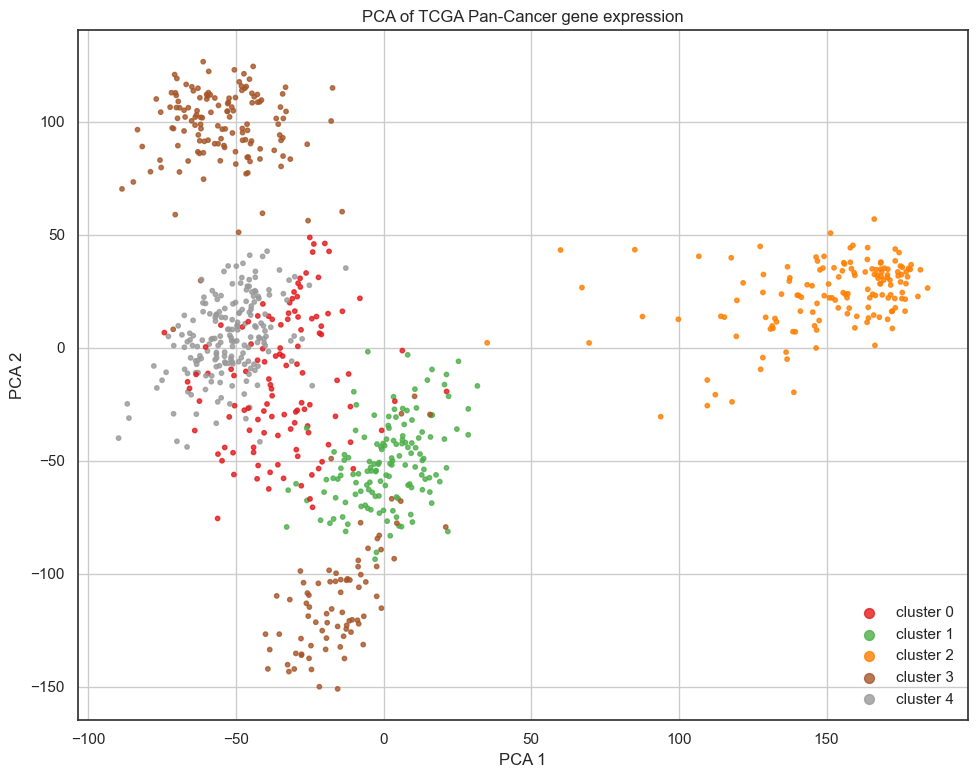

In [316]:
cluster_labels = clustering_pipeline(X, k=5, dim_red_method='tSNE', cluster_method='kmeans')

plot_dim_reduced_clustering(X, cluster_labels, method='PCA')

Clustering with __Spectral Clustering__ on dimension reduced data using __PCA__ and k=5:

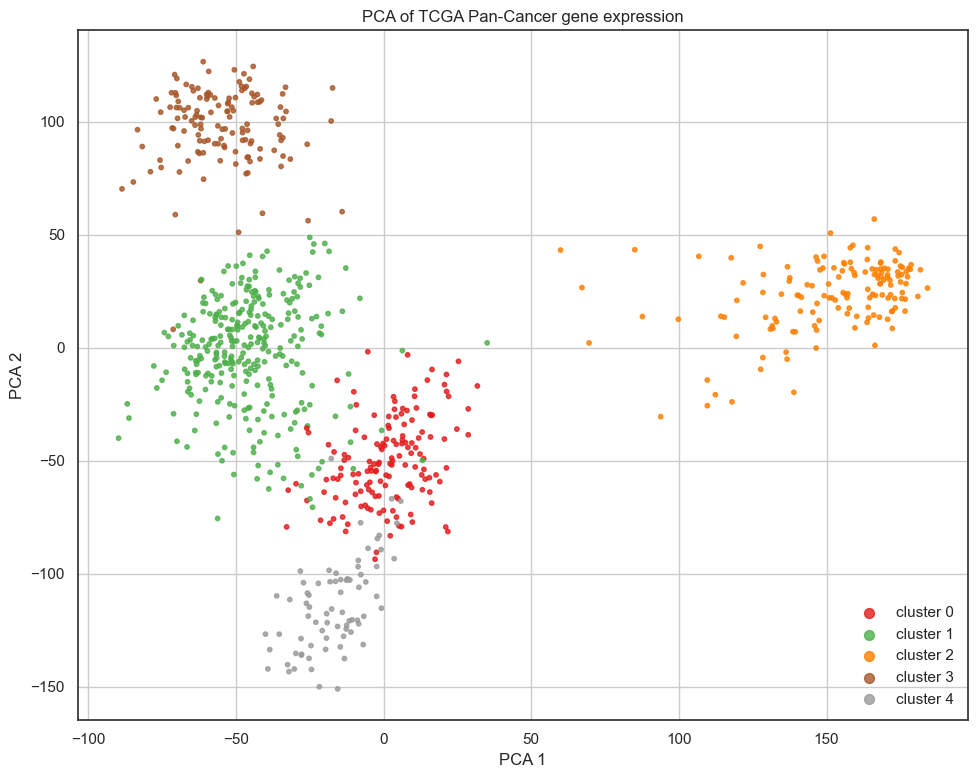

In [317]:
cluster_labels = clustering_pipeline(X, k=5, dim_red_method='PCA', cluster_method='spectral')

plot_dim_reduced_clustering(X, cluster_labels, method='PCA')

If we did not have knowledge about the true number of classes/clusters in the data, we may consider many possible values for k.

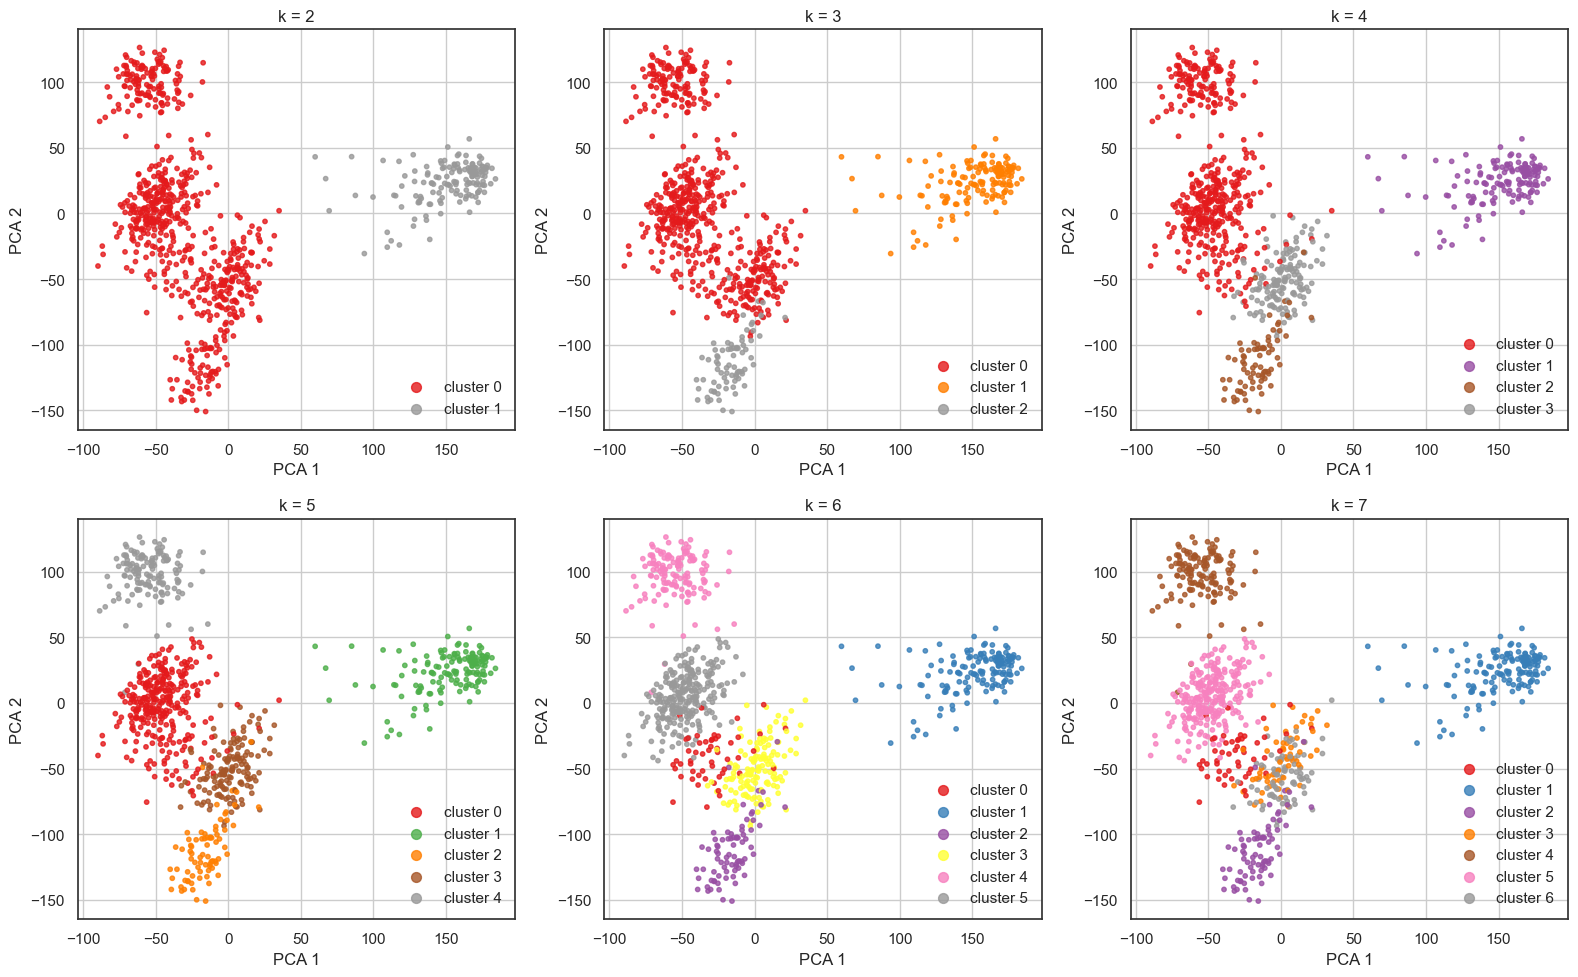

In [318]:
ks = range(2, 8)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, k in zip(axes.flat, ks):
    labels = clustering_pipeline(
        X,
        k=k
    )
    
    plot_dim_reduced_clustering(
        X,
        labels,
        method='PCA',
        ax=ax,
        show=False
    )
    ax.set_title(f'k = {k}')

plt.tight_layout()
plt.show()

If we did not know that the true number of clusters is k=5, we would want to ask ourselves: which of these options is the most truthful?

### 1.2 Cluster Validation:

In [282]:
num_cores = max(1, multiprocessing.cpu_count() - 1)

ks = list(range(2, 8))

The __Silhouette Statistic__ (Rousseeuw, 1986) evaluates how well each object lies within its assigned cluster by comparing its cohesion to its separation. For every object, it first measures the average distance to all other points in the same cluster and then measures the average distance to points in the nearest neighbouring cluster. The resulting silhouette value ranges from –1 to 1: 
- values near 1 indicate that the object is appropriately clustered and far from neighbouring clusters
- values around 0 suggest it lies between clusters, and negative values signal potential misclassification. 

By averaging these values over all objects, one obtains a concise overall score for each choice of k. The optimal number of clusters is then chosen as the k that yields the highest average silhouette score.

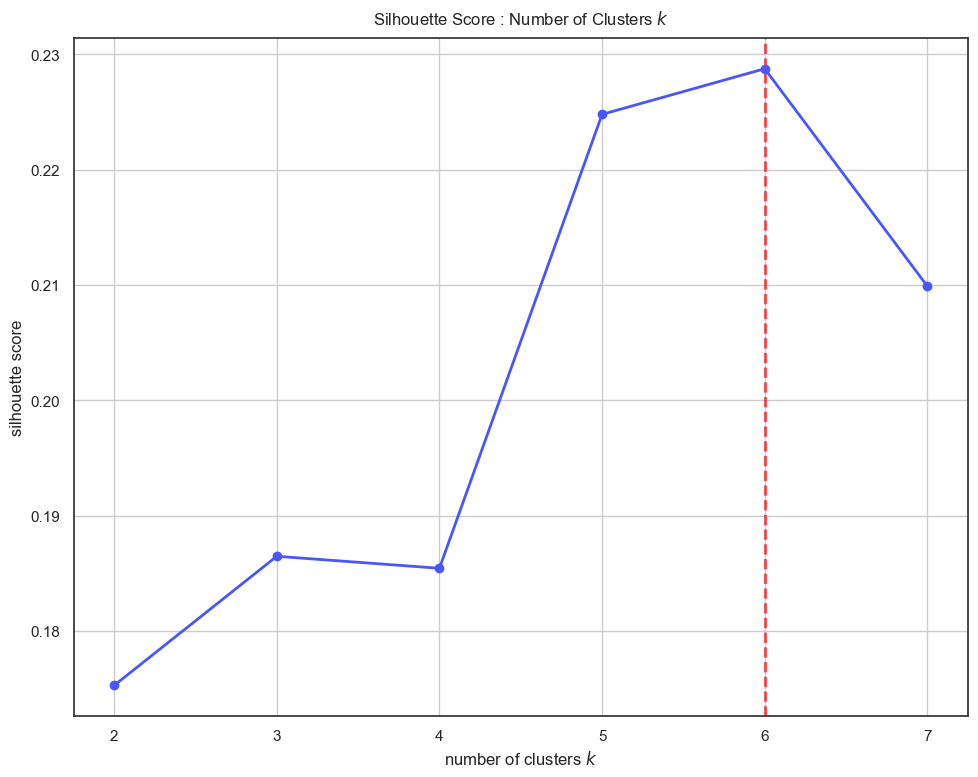

In [283]:
sil_scores = []
for k in ks:
    labels = clustering_pipeline(X, k=k)
    sil_score = silhouette_score(X, labels)  
    sil_scores.append(sil_score)
    
best_idx = int(np.argmax(sil_scores))
best_k = ks[best_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.errorbar(ks, sil_scores, fmt='-o')

ax.axvline(best_k, linestyle='--', alpha=0.7, color='red')

ax.set_title('Silhouette Score : Number of Clusters $k$', pad=10)
ax.set_xlabel("number of clusters $k$")
ax.set_ylabel('silhouette score')

plt.tight_layout()
plt.show()

The __Model Explorer Algorithm__ (Ben-Hur et al., 2002) evaluates the stability of a k-cluster solution by repeatedly drawing subsample pairs, clustering each subsample to k clusters, then intersecting the two subsamples and computing the adjusted rand index (ARI) on their common points. Doing this over many pairs produces a distribution of ARI scores for each k: when the data truly support k clusters, the distribution is peaked near 1 (high mean & low variance). As k increases past the ‘true’ value, the ARI distribution broadens and its mean drops, signalling a loss of inherent structure. The optimal k is taken as the largest value before this stability collapse—giving a model-free, shape-agnostic criterion that also flags when no real clusters exist.

(_The following cell takes about 2.5 minutes to run (for total iters = 100) on a MacBook Pro with an M3 Pro chip with 10 utilized cores._)

validating k=2 ...
validating k=3 ...
validating k=4 ...
validating k=5 ...
validating k=6 ...
validating k=7 ...


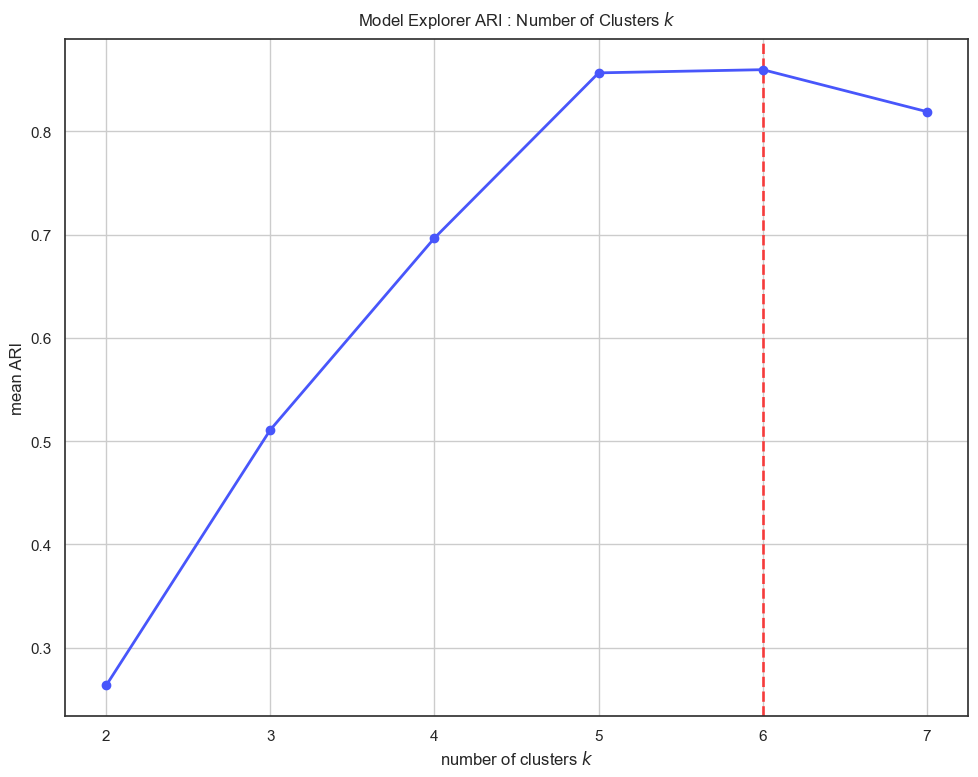

In [284]:
total_iters = 100
n_samples = X.shape[0]

def _model_explorer_iter(current_iter: int, k: int, rho: float = 0.8):
    # Subsample indices
    A, _ = subsample_indices(n_samples, ratio=rho, random_state=current_iter)
    B, _ = subsample_indices(n_samples, ratio=rho, random_state=current_iter+total_iters)
    
    # Cluster on A and B
    labels_A = clustering_pipeline(X[A], k=k)
    labels_B = clustering_pipeline(X[B], k=k)
    
    # Compute model-explorer ARI
    _, pos_A, pos_B = np.intersect1d(A, B, return_indices=True)
    ari = adjusted_rand_score(labels_A[pos_A], labels_B[pos_B])

    return ari

ari_arr = []
for k in ks:
    print(f'validating k={k} ...')
    
    results = Parallel(n_jobs=num_cores)(
        delayed(_model_explorer_iter)(current_iter=s, k=k) 
        for s in range(total_iters)
    )
    
    ari_arr.append(np.mean(results))

best_idx = int(np.argmax(ari_arr))
best_k = ks[best_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.errorbar(ks, ari_arr, fmt='-o')

ax.axvline(best_k, linestyle='--', alpha=0.7, color='red')

ax.set_title('Model Explorer ARI : Number of Clusters $k$', pad=10)
ax.set_xlabel("number of clusters $k$")
ax.set_ylabel('mean ARI')

plt.tight_layout()
plt.show()

__Consensus Clustering__ (Monti et al., 2003) assesses the robustness of a clustering solution by aggregating information across many clustering runs on perturbed datasets. For each k, the algorithm repeatedly resamples a subset of the data (typically 80%), clusters it into k groups, and records which sample pairs co-occur in the same cluster. These co-occurrence matrices are averaged to form a "consensus matrix": a symmetric similarity matrix reflecting how consistently each pair is clustered together. A highly stable k yields a block-diagonal consensus matrix with entries close to 0 or 1, indicating clear and reproducible grouping. 

(_The following cell takes about 1.25 minutes to run (for total iters = 100) on a MacBook Pro with an M3 Pro chip with 10 utilized cores._)

validating k=2 ...
validating k=3 ...
validating k=4 ...
validating k=5 ...
validating k=6 ...
validating k=7 ...


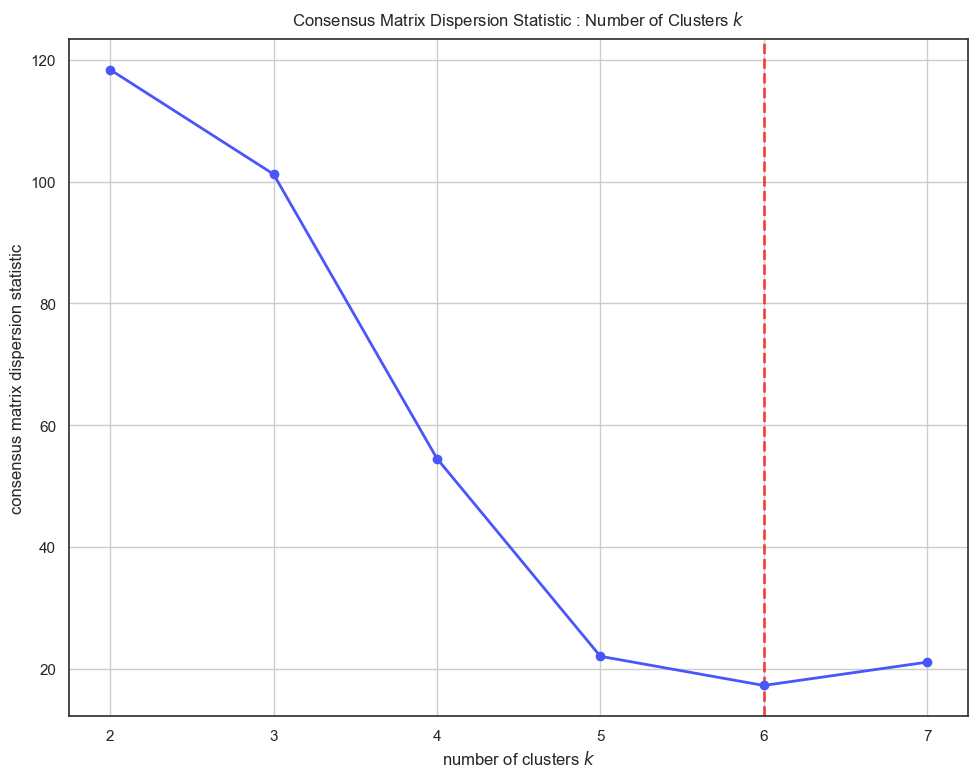

In [292]:
total_iters = 100
n_samples = X.shape[0]

def _cons_clustering_iter(current_iter: int, k: int, rho: float = 0.8):
    A, _ = subsample_indices(n_samples, ratio=rho, random_state=current_iter)
    labels_A = clustering_pipeline(X[A], k=k)
    return labels_A, A

dispersion_stat_arr = []
C_arr = []
for k in ks:
    print(f'validating k={k} ...')
    results = Parallel(n_jobs=num_cores)(
        delayed(_cons_clustering_iter)(current_iter=s, k=k)
        for s in range(total_iters)
    )

    assoc_count = np.zeros((n_samples, n_samples), dtype=float)
    co_occur = np.zeros((n_samples, n_samples), dtype=float)

    for labels, A in results:
        eq = (labels[:, None] == labels[None, :]).astype(float)  # build “same‐cluster” mask
        assoc_count[np.ix_(A, A)] += eq  # add to global assoc_count at respective rows/cols
        co_occur[np.ix_(A, A)] += 1  # for every pair i,j in A, increment co-occurred

    # do: consensus = assoc_count / co_occur, if co_occur>0
    C = np.zeros_like(assoc_count)
    mask = co_occur > 0
    C[mask] = assoc_count[mask] / co_occur[mask]
    C = np.nan_to_num(C, nan=0.0)
    C = np.clip(C, 0.0, 1.0)

    # calc instability
    dispersion_stat = np.mean(np.sum(C * (1 - C), axis=1))

    # reorder consensus matrix
    dist = np.clip(1 - C, 0.0, None)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method='average')
    order = leaves_list(Z)
    C = C[order][:, order]

    dispersion_stat_arr.append(dispersion_stat)
    C_arr.append(C)

best_idx = int(np.argmin(dispersion_stat_arr))
best_k = ks[best_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.errorbar(ks, dispersion_stat_arr, fmt='-o')
ax.axvline(best_k, linestyle='--', alpha=0.7, color='red')
ax.set_title('Consensus Matrix Dispersion Statistic : Number of Clusters $k$', pad=10)
ax.set_xlabel("number of clusters $k$")
ax.set_ylabel('consensus matrix dispersion statistic')
plt.tight_layout()
plt.show()

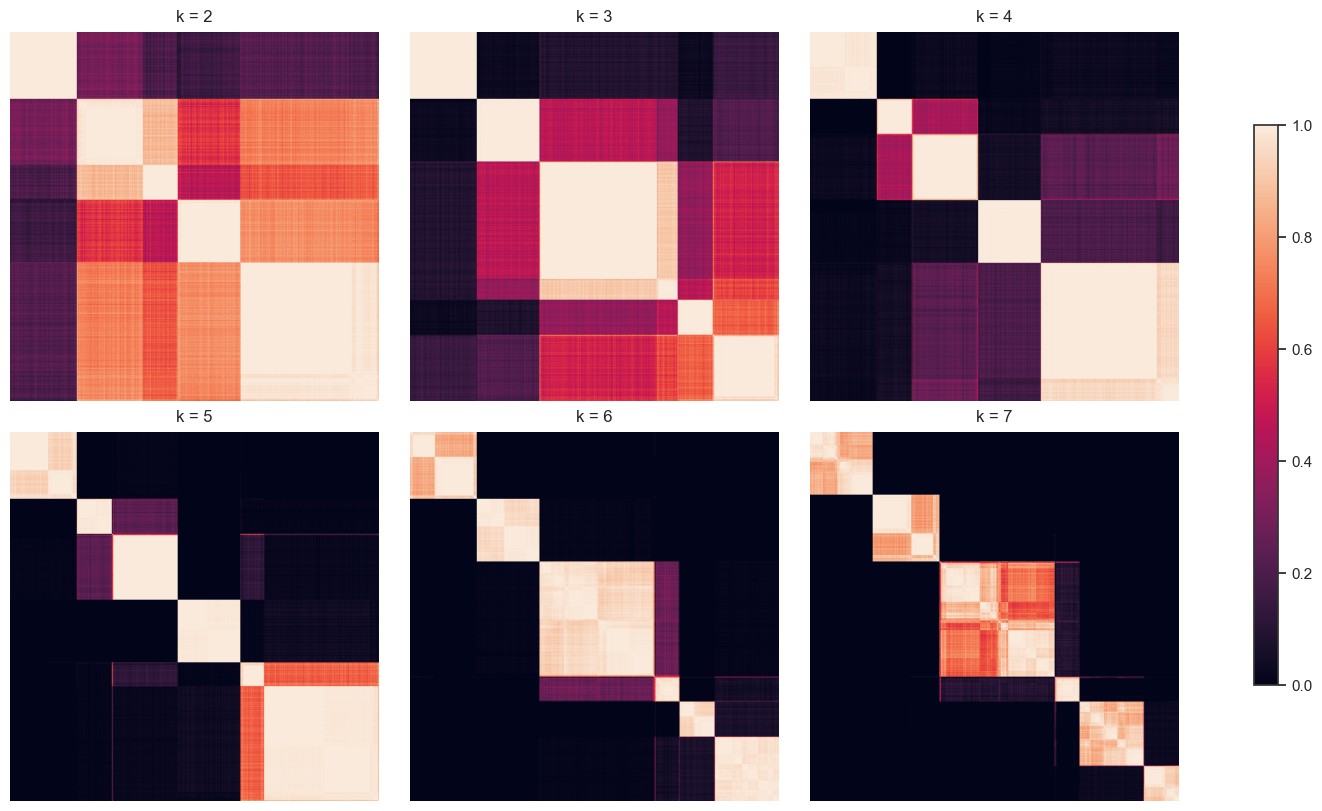

In [295]:
n_plots = len(ks)
n_cols  = 3
n_rows  = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    constrained_layout=True
)
axes = axes.flatten()

for ax, k_val, C in zip(axes, ks, C_arr):
    im = ax.imshow(C, aspect='equal')
    ax.set_title(f'k = {k_val}', pad=8)
    ax.axis('off')

for ax in axes[n_plots:]:
    ax.axis('off')

# add standalone colorbar
cax = fig.add_axes([1.05, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cax)

plt.show()

A __Generalizability/Predictive Stability__ method, as the one impelemnted below, inspired by Dudoit & Fridlyand (2002), evaluates the inherent reproducibility of a k-cluster solution by using resampling and classification to measure how well cluster structure generalizes to new samples. For each candidate number of clusters k, one performs S iterations (e.g. 100):

1. Resample: draw a ρ-fraction training set A_train and define the complementary test set A_test.
2. Cluster: apply a clustering algorithm separately to A_train and A_test to obtain label vectors c_train and c_test.
3. Classify: train a random forest classifier on (A_train, c_train), then predict cluster labels for A_test.
4. Score: compute the adjusted Rand index (ARI) between the true test labels c_test and the predicted labels.

Aggregating over all S iterations yields a distribution of ARI scores for each k: when the data support k genuine clusters, the mean ARI is high (and variance low), reflecting stable, learnable structure.  Plotting mean(ARI) versus k and selecting the k with the maximal predictive ARI provides a model-free, classifier-based criterion for estimating the “true” number of clusters, grounded in how well cluster assignments can be predicted on held-out data.


(_The following cell takes about 3.5 minutes to run (for total iters = 100) on a MacBook Pro with an M3 Pro chip with 10 utilized cores._)

validating k=2 ...
validating k=3 ...
validating k=4 ...
validating k=5 ...
validating k=6 ...
validating k=7 ...


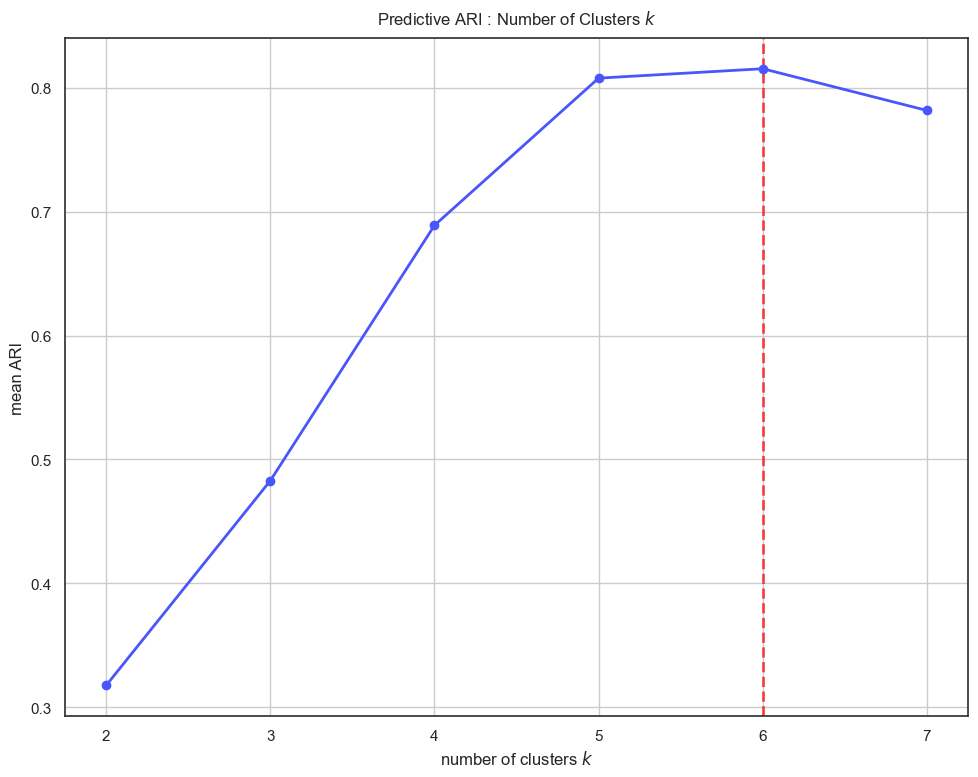

In [296]:
total_iters = 100
n_samples, p = X.shape

def _pred_clustering_iter(current_iter: int, rho: float = 0.8):
    A_train, A_test = subsample_indices(n_samples, ratio=rho, random_state=current_iter)
    
    labels_A_train = clustering_pipeline(X[A_train], k=k)
    labels_A_test = clustering_pipeline(X[A_test], k=k)
    
    rf_A = RandomForestClassifier(n_estimators=100, max_depth=p, max_features=int(np.round(np.sqrt(p))), random_state=current_iter)
    rf_A.fit(X[A_train], labels_A_train)
    
    labels_A_test_pred = rf_A.predict(X[A_test])
    
    ari = adjusted_rand_score(labels_A_test, labels_A_test_pred)
    
    return ari

pred_ari_arr = []
for k in ks:
    print(f'validating k={k} ...')
    
    results = Parallel(n_jobs=num_cores)(
        delayed(_pred_clustering_iter)(current_iter=s)
        for s in range(total_iters)
    )
    
    pred_ari_arr.append(np.mean(results))

best_idx = int(np.argmax(pred_ari_arr))
best_k = ks[best_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.errorbar(ks, pred_ari_arr, fmt='-o')

ax.axvline(best_k, linestyle='--', alpha=0.7, color='red')

ax.set_title('Predictive ARI : Number of Clusters $k$', pad=10)
ax.set_xlabel("number of clusters $k$")
ax.set_ylabel('mean ARI')

plt.tight_layout()
plt.show()

So, we may conclude that for this particular pipeline, normalizing the data, using a PCA dimensionality reduction with n_components = 50, and clustering using KMeans, the optimal number of clusters seems be to k=6.

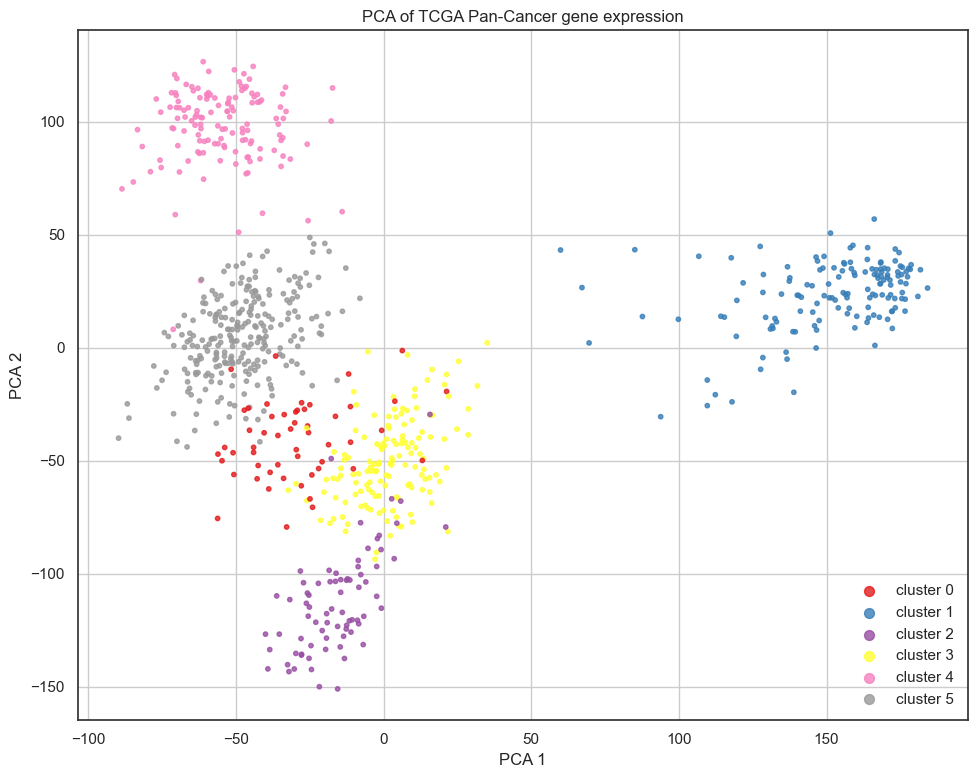

In [308]:
cluster_labels = clustering_pipeline(X, k=6)

plot_dim_reduced_clustering(X, cluster_labels, method='PCA')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


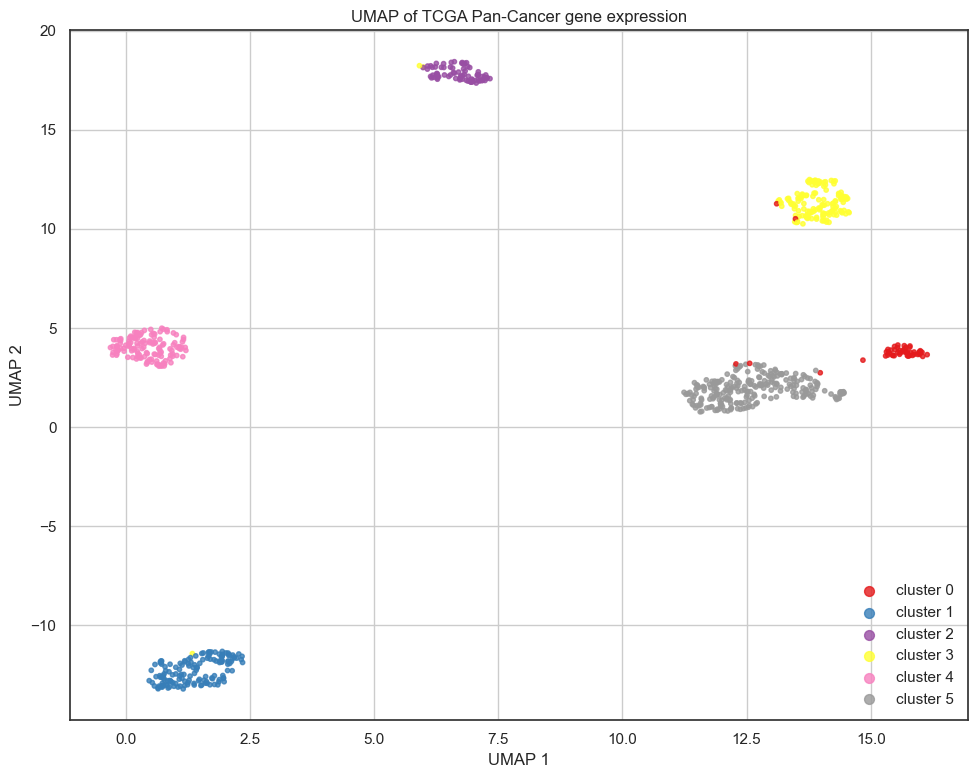

In [309]:
plot_dim_reduced_clustering(X, cluster_labels, method='UMAP')

---

## 2. ScanPy:

In this section of the notebook we want to consider how different choices in our clustering pipeline affect the optimal number of k. This is also intended to provide a different angle of motivation of the importance of clustering validation. 

To do so, we will consider a popular and widely used Pytchon package for single-cell data analysis

### 2.1 Default Values:

In [218]:
adata = sc.AnnData(X)

A typical default data analysis pipeline with ScanPy would go through the following steps; all hyperparameters are set to their default values:

1. Compute a k-nearest-neighbors graph:
    - n_neighbors=15: for each sample, find its 15 closest neighbors.
    - n_pcs=None: without PCA.
    - method='umap': method used for computing connectivities. (Can be set to 'umap' (default) or 'gauss'.)
2. Run the leiden community-detection algorithm (Traag et al., 2019) on the neighbor graph. The Leiden algorithm is an improved version of the Louvain algorithm (Blondel et al., 2008). It was proposed for single-cell analysis by Levine et al. (2015).
    - resolution=1: controls granularity of clusters
        - lower: fewer, larger clusters
        - higher: more, smaller clusters
    - n_iterations=-1: has the algorithm run until it reaches its "optimal clustering".

In [311]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=None, use_rep='X', method='umap', random_state=0)
sc.tl.leiden(adata, resolution=1, random_state=0, key_added='leiden_opt', n_iterations=-1)

labels = adata.obs['leiden_opt'].astype(int)
optimal_k = labels.nunique()

print(f"scanpy-chosen k: k={optimal_k}")

scanpy-chosen k: k=7


We can see that by this default pipeline with all hyperparameters set to their default values, we get an optimal k=7 – in other words, the default pipeline overclusters.

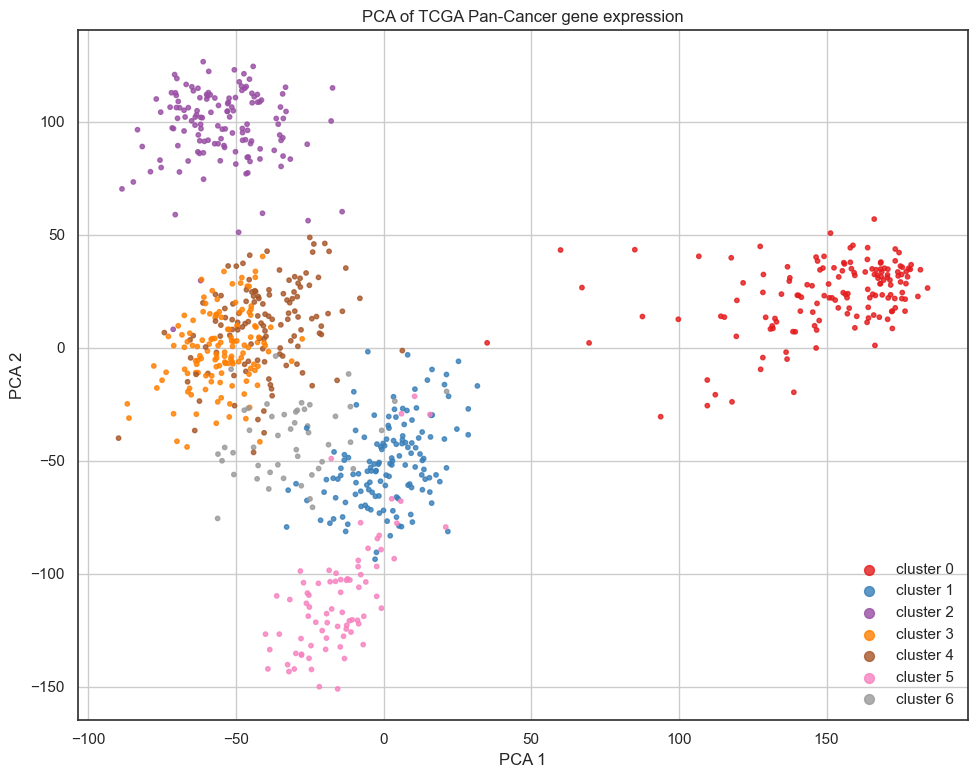

In [312]:
plot_dim_reduced_clustering(X, labels, method='PCA')

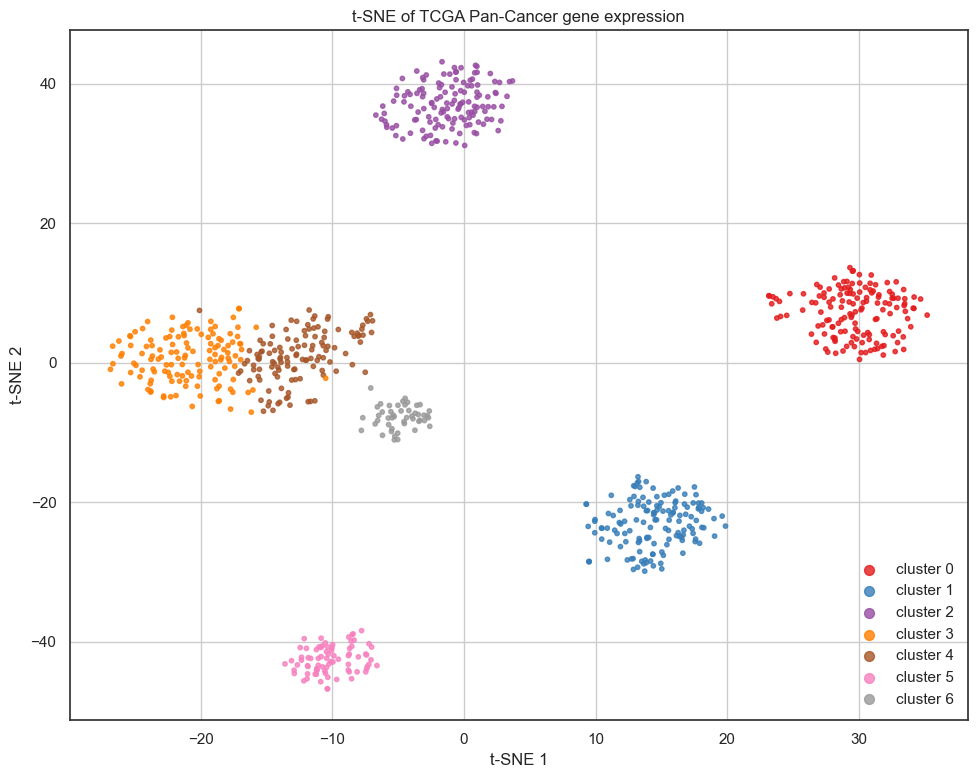

In [314]:
plot_dim_reduced_clustering(X, labels, method='tSNE')

### 2.2 ScanPy Stability Analysis

We will now iterate over many possible analysis pipelines with ScanPy and track the determined optimal number of clusters. 


(_Running the analysis takes about 1.5 minutes to run (for total iters = 100) on a MacBook Pro with an M3 Pro chip with 10 utilized cores._)

In [226]:
param_dist = {
    "preproc": ["raw", "normalized", "log1p"],
    "n_neighbors": np.arange(5, 51, 5),
    "n_pcs": np.arange(10, 101, 5),
    "method": ["umap", "gauss"],
    "resolution": np.linspace(0.1, 2.0, 20),
    "random_state":[0, 7, 13, 42, 99]
}

n_iter = 1000
sampler = ParameterSampler(param_dist, n_iter=n_iter, random_state=0)

In [ ]:
num_cores = max(1, multiprocessing.cpu_count() - 1)

def _run_param(params):
    ad = adata.copy()
    if params["preproc"] == "normalized":
        sc.pp.normalize_total(ad)
    elif params["preproc"] == "log1p":
        sc.pp.normalize_total(ad)
        sc.pp.log1p(ad)

    sc.pp.neighbors(
        ad,
        n_neighbors=params["n_neighbors"],
        n_pcs=params["n_pcs"],
        use_rep='X',
        method=params["method"],
        random_state=params["random_state"]
    )
    
    sc.tl.leiden(
        ad,
        resolution=params["resolution"],
        random_state=params["random_state"],
        key_added="leiden_opt",
        n_iterations=-1
    )

    labels_opt = ad.obs["leiden_opt"].astype(int).values
    k_opt = labels_opt.max() + 1
    ari = adjusted_rand_score(y, labels_opt)

    return {**params, "k": k_opt, "ari_vs_true": ari}

results = Parallel(n_jobs=num_cores)(
    delayed(_run_param)(p) for p in sampler
)

df = pd.DataFrame(results)

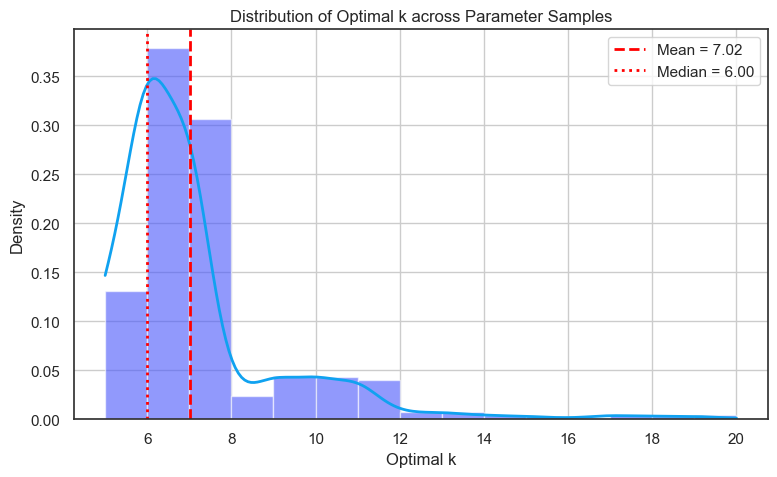

Mean of k: 7.02
Median of k: 6.00
Variance of k: 4.39


In [242]:
k_values = df['k'].values

mean_k = k_values.mean()
median_k = np.median(k_values)
variance_k = k_values.var()

kde = gaussian_kde(k_values)
x_grid = np.linspace(k_values.min(), k_values.max(), 200)

fig, ax = plt.subplots()
ax.hist(k_values, bins='auto', density=True, alpha=0.6)
ax.plot(x_grid, kde(x_grid), linewidth=2)
ax.axvline(mean_k, color="r", linestyle='--', label=f"Mean = {mean_k:.2f}")
ax.axvline(median_k, color="r", linestyle=':', label=f"Median = {median_k:.2f}")
ax.set_xlabel('Optimal k')
ax.set_ylabel('Density')
ax.set_title('Distribution of Optimal k across Parameter Samples')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of k: {mean_k:.2f}")
print(f"Median of k: {median_k:.2f}")
print(f"Variance of k: {variance_k:.2f}")

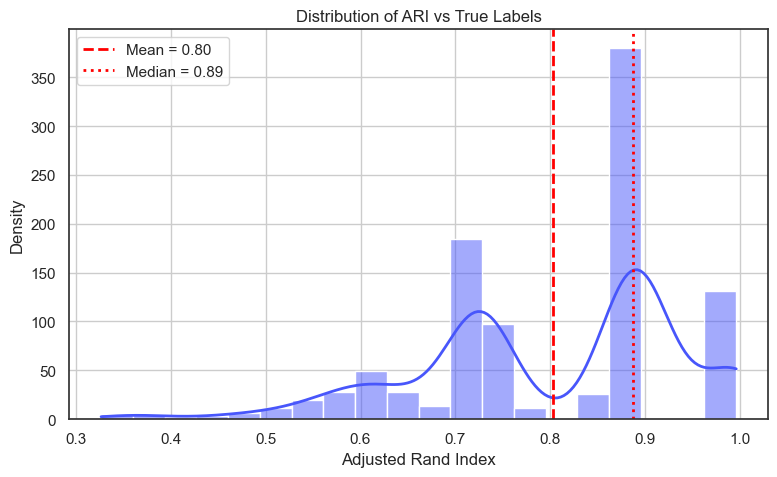

Mean of ARIs: 0.80
Median of ARIs: 0.89
Variance of ARIs: 0.02


In [243]:
ari_values = df['ari_vs_true'].values

mean_k = ari_values.mean()
median_k = np.median(ari_values)
variance_k = ari_values.var()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["ari_vs_true"], kde=True, ax=ax)
ax.axvline(mean_k, color="r", linestyle='--', label=f"Mean = {mean_k:.2f}")
ax.axvline(median_k, color="r", linestyle=':', label=f"Median = {median_k:.2f}")
ax.set_title("Distribution of ARI vs True Labels")
ax.set_xlabel("Adjusted Rand Index")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of ARIs: {mean_k:.2f}")
print(f"Median of ARIs: {median_k:.2f}")
print(f"Variance of ARIs: {variance_k:.2f}")

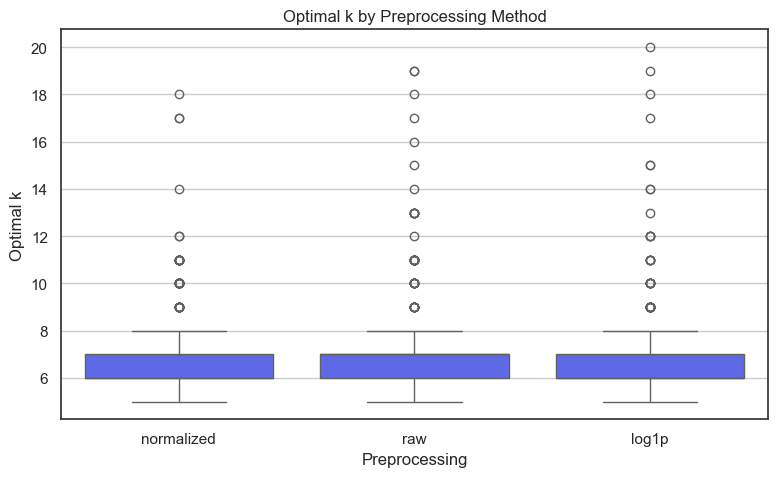

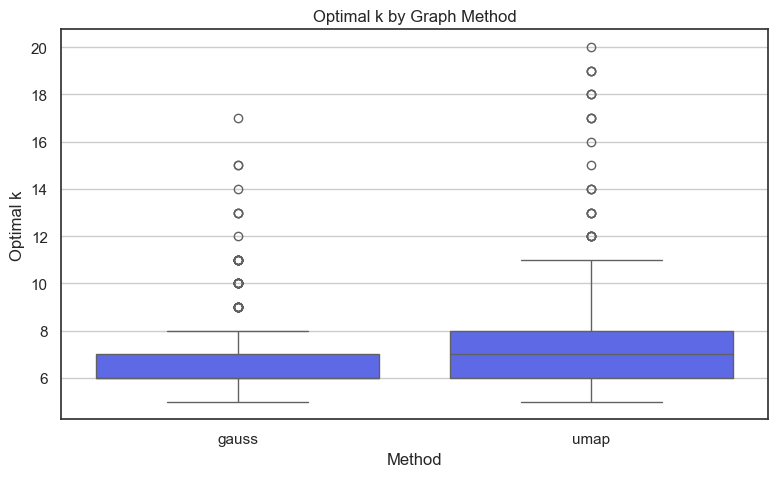

In [244]:
# preprocessing
fig, ax = plt.subplots()
sns.boxplot(x="preproc", y="k", data=df, ax=ax)
ax.set_title("Optimal k by Preprocessing Method")
ax.set_xlabel("Preprocessing")
ax.set_ylabel("Optimal k")
plt.tight_layout()

# method
fig, ax = plt.subplots()
sns.boxplot(x="method", y="k", data=df, ax=ax)
ax.set_title("Optimal k by Graph Method")
ax.set_xlabel("Method") 
ax.set_ylabel("Optimal k")
plt.tight_layout()

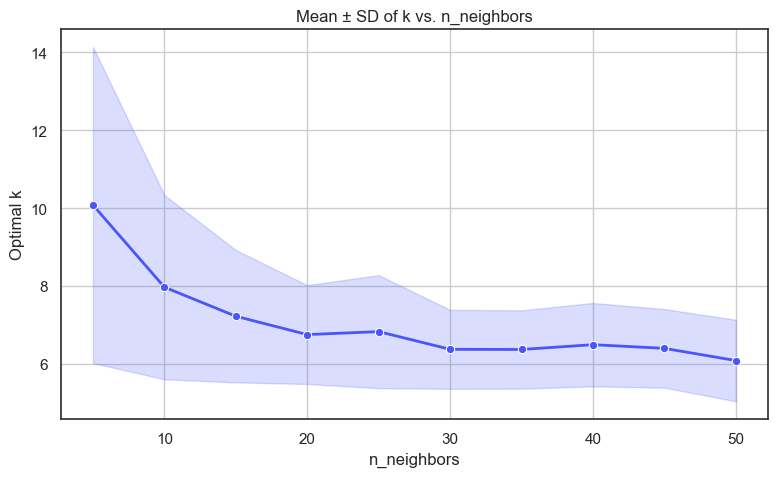

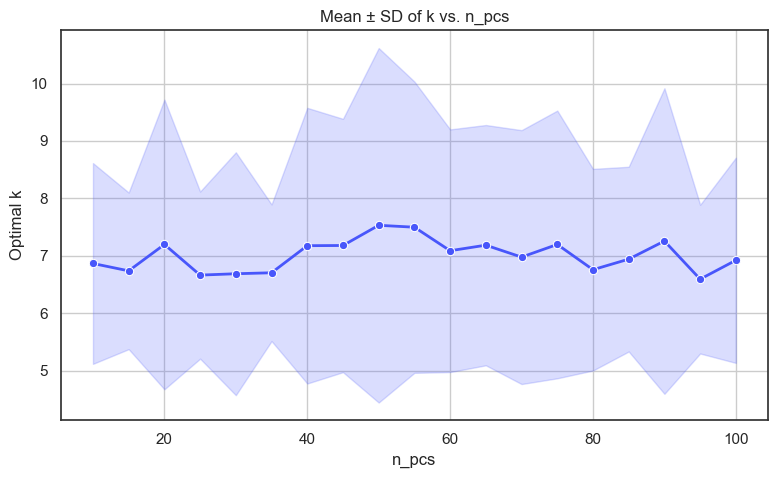

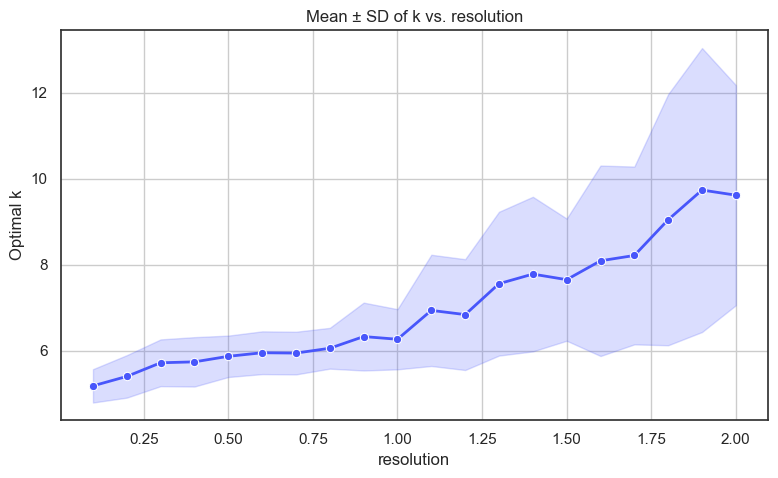

In [245]:
for param in ["n_neighbors", "n_pcs", "resolution"]:
    fig, ax = plt.subplots()

    sns.lineplot(
        x=param, y="k", 
        data=df, 
        estimator="mean", 
        errorbar="sd", 
        marker="o", 
        ax=ax
    )
    ax.set_title(f"Mean ± SD of k vs. {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Optimal k")
    plt.tight_layout()

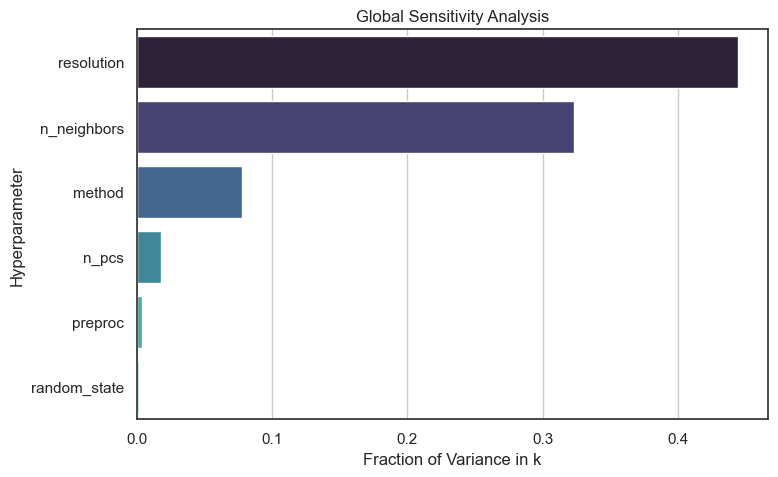

In [246]:
total_var = df["k"].var()
sensi = {
    param: df.groupby(param)["k"].mean().var() / total_var
    for param in ["preproc", "method", "n_neighbors", "n_pcs", "resolution", "random_state"]
}
sensi = pd.Series(sensi).sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=sensi.values, y=sensi.index, palette="mako", hue=sensi.index, ax=ax)
ax.set_xlabel("Fraction of Variance in k")
ax.set_ylabel("Hyperparameter")
ax.set_title("Global Sensitivity Analysis")
plt.tight_layout()

This small simulation study has shown how widely results can vary accross different pre-processing steps, dimensionality reduction methods, and clustering hyperparameters and motivates again the necessity for proper clustering validation.